## Inspecting the supplied dataset

By default, we look at `train.pickle` as it is a larger dataset. However, it is also possible to study `test.pickle`, which may yield you different results.

In [47]:
import pickle as pkl
import pandas
import numpy as np

DATASETS_PATH = os.path.join('..','data')
TEST_DATASET_PATH = os.path.join(DATASETS_PATH, 'train.pickle')

# open test and train dataset with pickle - the resulting object is a pandas.DataFrame
with open(TEST_DATASET_PATH, 'rb') as f:
    test_dataset = pkl.load(f)

/tmp/ipykernel_653/2413941758.py:10: DeprecationWarning: numpy.core.numeric is deprecated and has been renamed to numpy._core.numeric. The numpy._core namespace contains private NumPy internals and its use is discouraged, as NumPy internals can change without warning in any release. In practice, most real-world usage of numpy.core is to access functionality in the public NumPy API. If that is the case, use the public NumPy API. If not, you are using NumPy internals. If you would still like to access an internal attribute, use numpy._core.numeric._frombuffer.
  test_dataset = pkl.load(f)


In [48]:
selected_data = test_dataset
# selected_data = test_dataset.query('label == 2')

dataset = np.array(list(selected_data['sensor_data']), dtype=np.float32)
labels = np.array(list(selected_data['label']))

num_data = dataset.shape[0]
dataset.shape

(4053, 128, 6)

### Look at the dataset

We want to visually inspect the dataset. How does an average time series look like? Are there any outliers or distinguishing features?
If you have JupyterLab this works very well to inspect all data. 

In [49]:
from ipywidgets import interact, IntSlider
from utils import show_dataset

FAILURE_CLASSES = [
    ("0-0-0-0", "All brakes intact (no irregularities)."),
    ("0-0-1-0", "Rear Left Brake with irregularity."),
    ("0-0-0-1", "Rear Right Brake with irregularity."),
    ("0-0-1-1", "Both Rear Brakes with irregularities."),
    ("1-0-0-0", "Front Left Brake with irregularity."),
    ("0-1-0-0", "Front Right Brake with irregularity."),
    ("1-1-0-0", "Both Front Brakes with irregularities."),
    ("1-0-1-0", "Left Brakes (Front + Rear Left) with irregularities."),
    ("0-1-0-1", "Right Brakes (Front + Rear Right) with irregularities."),
    ("1-0-0-1", "Front Left and Rear Right Brakes with irregularities."),
    ("0-1-1-0", "Front Right and Rear Left Brakes with irregularities."),
    ("1-1-1-1", "All Brakes with irregularities.")
]

@interact(index=IntSlider(min=0,max=num_data-1,step=1,value=0))
def show(index):
    fig = show_dataset(dataset[index])
    fig.suptitle("mean curve - {}".format(FAILURE_CLASSES[labels[index]][0]))

interactive(children=(IntSlider(value=0, description='index', max=4052), Output()), _dom_classes=('widget-inte…

### Computing the mean curve

Let's try to generalize the curve behavior by computing the mean and variance. This may help us understand large deviations and/or correlations. 

In [50]:
# compute the mean and standard deviation for every timestep + dimension
mean = np.mean(dataset, axis=0)
variance = np.std(dataset, axis=0)

upper = mean + variance
lower = mean - variance

In [51]:
# plot the time-based variance and mean
import matplotlib.pyplot as plt

def plot(mean, lower, upper):
    samples = np.arange(mean.shape[0])
    fig, axes = plt.subplots(3,2)

    directions = ['x','y','z']
    value_type = ['acceleration', 'rotation']

    for i, direction_label in enumerate(directions):
        for j, value_label in enumerate(value_type):
            axes[i,j].fill_between(samples, lower[...,j*3 + i], upper[...,j*3 + i], alpha=0.5)
            axes[i,j].plot(samples, mean[...,j*3+i], color='red')
            if i == 0:
                axes[i,j].set_title(value_label)
            
            if j == 1:
                axes[i,j].text(1,0.5,direction_label, size=12, rotation=270, transform=axes[i,j].transAxes)

    return fig

### Show the mean curve

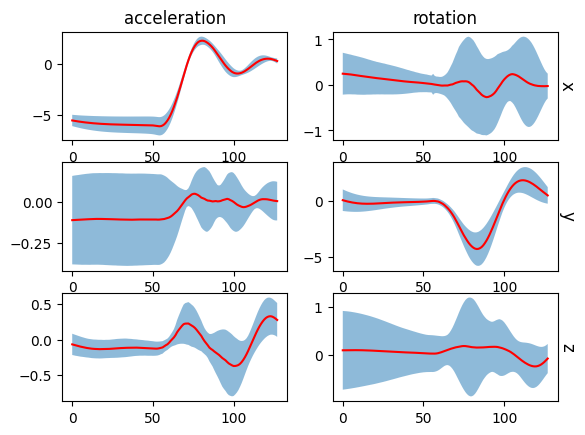

In [52]:
plot(mean, lower, upper).show()

### Compute the mean for each class

It is not useful to look at the mean curve of the whole dataset. We can also just look at a single classification and their mean curve. 
This may help us understand distinguishing features between different classifications.

In [53]:
from task2.gan.utils import generate_mean_by_class

mean_test = generate_mean_by_class(test_dataset)
mean_test.shape

(12, 128, 6)

### Show the mean curve by classification

In [54]:
from ipywidgets import interact, IntSlider
from task2.gan.utils import show_dataset

FAILURE_CLASSES = [
    ("0-0-0-0", "All brakes intact (no irregularities)."),
    ("0-0-1-0", "Rear Left Brake with irregularity."),
    ("0-0-0-1", "Rear Right Brake with irregularity."),
    ("0-0-1-1", "Both Rear Brakes with irregularities."),
    ("1-0-0-0", "Front Left Brake with irregularity."),
    ("0-1-0-0", "Front Right Brake with irregularity."),
    ("1-1-0-0", "Both Front Brakes with irregularities."),
    ("1-0-1-0", "Left Brakes (Front + Rear Left) with irregularities."),
    ("0-1-0-1", "Right Brakes (Front + Rear Right) with irregularities."),
    ("1-0-0-1", "Front Left and Rear Right Brakes with irregularities."),
    ("0-1-1-0", "Front Right and Rear Left Brakes with irregularities."),
    ("1-1-1-1", "All Brakes with irregularities.")
]
@interact(index=IntSlider(min=0,max=11,step=1,value=0))
def show(index):
    fig = show_dataset(mean_test[index])
    fig.suptitle("mean curve - {}".format(FAILURE_CLASSES[index][0]))

interactive(children=(IntSlider(value=0, description='index', max=11), Output()), _dom_classes=('widget-intera…